In [1]:
import json
import os
from google.colab import userdata

try:
    # Busca as chaves no Secrets do Colab
    username = userdata.get("KAG_USER")
    key = userdata.get("KAG_KEY")

    # Configura o Kaggle
    dados_api = {"username": username, "key": key}
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    caminho_json = os.path.expanduser("~/.kaggle/kaggle.json")
    with open(caminho_json, "w") as f:
        json.dump(dados_api, f)
    os.chmod(caminho_json, 0o600)
    print("Kaggle autenticado via Secrets")

    #Download do Dataset de carros e motos
    !kaggle datasets download utkarshsaxenadn/car-vs-bike-classification-dataset
    print("Dataset pronto para uso")

except Exception as e:
    print("Erro na autenticação")

Kaggle autenticado via Secrets
Dataset URL: https://www.kaggle.com/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset
License(s): CC0-1.0
100% 103M/103M [00:00<00:00, 156MB/s] 

Dataset pronto para uso


In [2]:
!unzip -q car-vs-bike-classification-dataset.zip -d carro_vs_moto/

In [3]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Caminho único para a pasta raiz que contém as duas classes
DATA_DIR = "carro_vs_moto/Car-Bike-Dataset/"
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32
EPOCHS = 20

#Carregamento do dataset de treino (80% dos dados)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,  # Reserva 20% das imagens para validação
    subset="training",  # Define que este subconjunto é para treino
    seed=123,  # SEED idêntica em ambos para não misturar os dados
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

#Carregamento do dataset de validação (20% dos dados)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,  # A mesma SEED garante que o corte seja feito no mesmo lugar
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

#Nome das classes
class_names = train_ds.class_names
print(class_names)

#Otimização de performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
['Bike', 'Car']


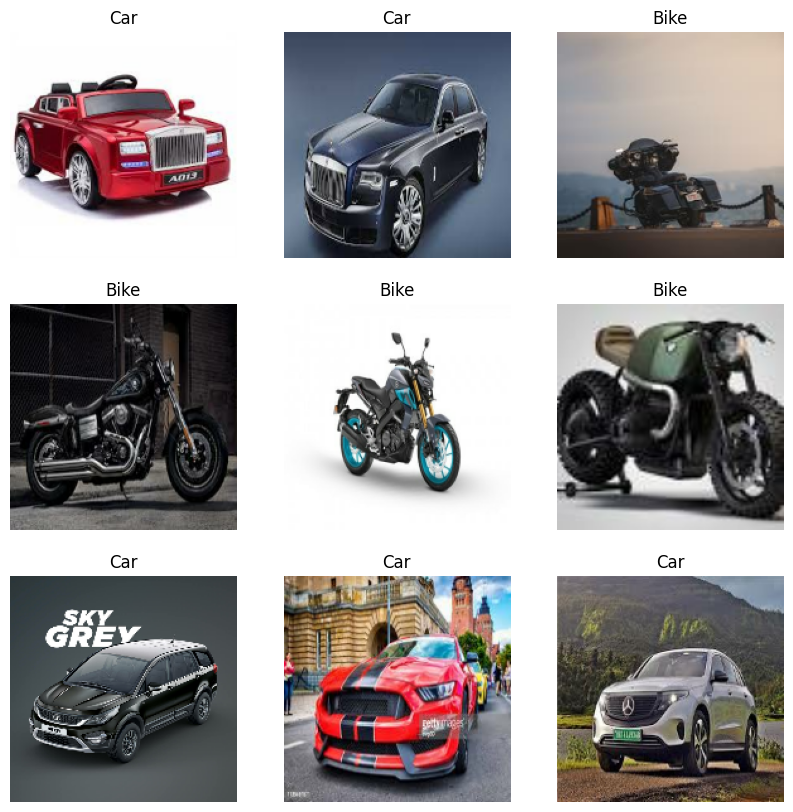

In [11]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.show()

In [5]:
for classe in os.listdir(DATA_DIR):
    caminho = os.path.join(DATA_DIR, classe)
    if os.path.isdir(caminho):
        print(f"{classe}: {len(os.listdir(caminho))} imagens")

Car: 2000 imagens
Bike: 2000 imagens


In [6]:
for images, labels in train_ds.take(1):
    print("Shape do batch:", images.shape)
    print("Shape dos labels:", labels.shape)

Shape do batch: (32, 180, 180, 3)
Shape dos labels: (32, 1)


In [9]:
# Data Augmentation
data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
])

model = models.Sequential([
        keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        data_augmentation,

        layers.Rescaling(1./255),

        # Bloco 1 Convolução
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Bloco 2 Convolução
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Bloco 3 Convolução
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),

        #1 neurônio com ativação Sigmoid para classificação binária
        layers.Dense(1, activation="sigmoid"),
])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,032,449 (30.64 MB)

 Trainable params: 8,032,001 (30.64 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.6322 - loss: 3.0830 - val_accuracy: 0.4875 - val_loss: 17.1743
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.7444 - loss: 0.5517 - val_accuracy: 0.4875 - val_loss: 20.2887
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.8116 - loss: 0.4278 - val_accuracy: 0.4875 - val_loss: 17.2507
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.8269 - loss: 0.3776 - val_accuracy: 0.4938 - val_loss: 8.1224
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.8278 - loss: 0.3862 - val_accuracy: 0.5150 - val_loss: 6.7258
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.8391 - loss: 0.3490 - val_accuracy: 0.5950 - val_loss: 4.3319
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.8541 - loss: 0.3374 - val_accuracy: 0.8975 - val_loss: 0.3094
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.8775 - loss

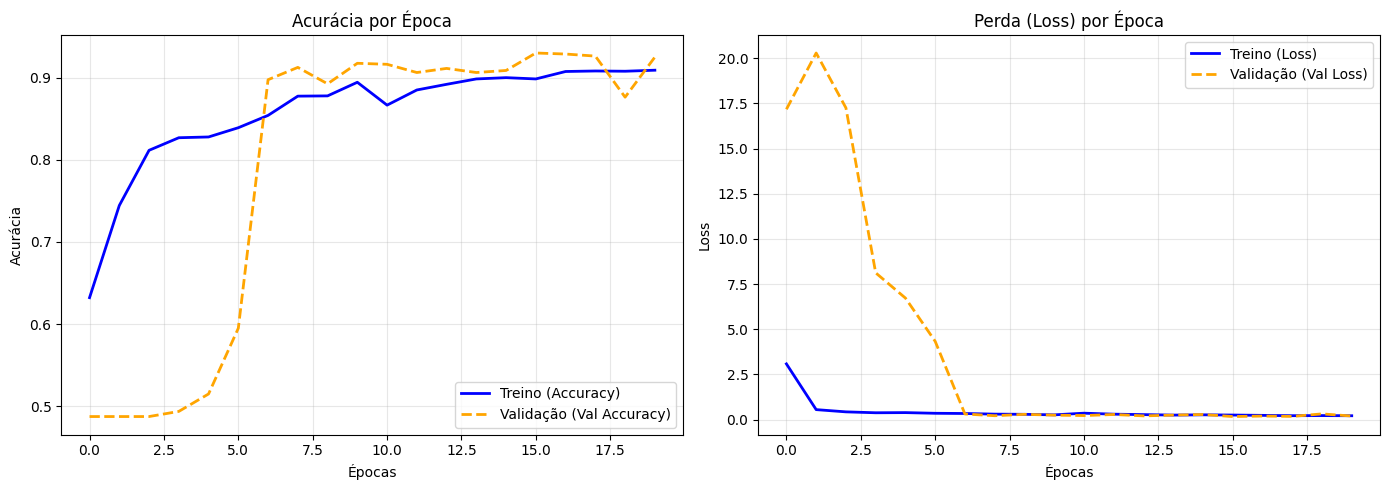

In [10]:
#Compilar modelo
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#Resumo da arquitetura no terminal
model.summary()

#Treinar modelo
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

#Gráficos
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

#Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Treino (Accuracy)", color="blue", lw=2)
plt.plot(
    epochs_range,
    val_acc,
    label="Validação (Val Accuracy)",
    color="orange",
    linestyle="--",
    lw=2,
)
plt.title("Acurácia por Época")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

#Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Treino (Loss)", color="blue", lw=2)
plt.plot(
    epochs_range,
    val_loss,
    label="Validação (Val Loss)",
    color="orange",
    linestyle="--",
    lw=2,
)
plt.title("Perda (Loss) por Época")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()